# AFC Lab — Fatigue Detection v8.1 (Stress Profile Embedding)

**Версия 8.1** — PhysioNet (Empatica E4, запястье): Exercise-only + **Subject Stress Profile**

## Ключевые решения v8.1:
- **Exercise-only обучение** — только AEROBIC + ANAEROBIC окна (как v7 baseline, F1=0.80)
- **Stress Profile Embedding** — ~13 признаков на субъект из STRESS-сессии + демография:
  - Self-reported stress: `sl_baseline`, `sl_peak`, `sl_reactivity`, `sl_mean_tasks`
  - Физиологическая реактивность: `hr_baseline`, `hr_tasks`, `hr_reactivity`, `eda_baseline`, `eda_tasks`, `eda_reactivity`
  - Демография: `age_norm`, `bmi_norm`, `gender`
- **Profile Dropout** p=0.3 — зануляет весь профиль, чтобы модель не полагалась только на него
- **FatigueWristNet** — classifier input расширен на +13 profile features
- **Ablation** — v7 baseline (без profile) vs v8.1 (с profile) + permutation importance

## Структура ноутбука:
1. Импорты, SEED, DEVICE
2. CONFIG v8.1
3. Загрузка exercise-данных (AEROBIC+ANAEROBIC из NPZ)
4. Извлечение стресс-профиля субъекта (STRESS + demographics)
5. Подготовка: subject-split, profiles → windows, аугментация, SMOTE
6. Архитектура: FatigueWristNet + Profile Embedding
7. Обучение: Focal Loss, AdamW, CosineAnnealing, EarlyStopping(EMA)
8. Оценка на тесте (F1-optimal + Recall-optimal thresholds)
9. LOSO кросс-валидация
10. Персонализация (fine-tuning)
11. Ablation: v7 baseline vs v8.1 (with profile) + Feature Importance

In [1]:
# ── 1. Imports ──
import os, sys, random
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.interpolate import interp1d

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.metrics import (
    f1_score, roc_auc_score, balanced_accuracy_score,
    confusion_matrix, classification_report, precision_recall_curve,
    auc, roc_curve,
)
from scipy.interpolate import CubicSpline
from scipy.signal import resample as sp_resample
from imblearn.over_sampling import SMOTE

sys.path.insert(0, str(Path.cwd().parent))
print(f"PyTorch: {torch.__version__}, CUDA: {torch.cuda.is_available()}")

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style('whitegrid')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

SEED = 4544655

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed: {SEED}")

PyTorch: 2.10.0+cu130, CUDA: True
Device: cuda
Seed: 4544655


## 2. CONFIG v8.1

Конфигурация на базе v7.0 (PhysioNet, Empatica E4) с добавлением Stress Profile Embedding.
Ключевые параметры: `profile_dim=13`, `profile_dropout=0.3`.

In [2]:
# --- Hyperparameters ---
# Best
# 

# Good


# BAD (overfitting, high precision but low recall)
#  
# 

In [3]:
CONFIG = {
    # --- Training ---
    'batch_size': 64,
    'epochs': 50,
    'lr': 1e-4,
    'weight_decay': 3e-2,
    'patience': 10,
    'min_delta': 2e-4,

    # --- Architecture: IMU Encoder ---
    'imu_channels': 6,
    'encoder_channels': 16,
    'encoder_dropout': 0.375,
    'kernel_sizes': [7, 5, 3],

    # --- Architecture: Physio Encoder ---
    'physio_channels': 4,
    'physio_encoder_channels': 8,

    # --- Architecture: Classifier ---
    'classifier_dropout': 0.55,

    # --- Stress Profile Embedding ---
    'profile_dim': 13,          # 4 self-report + 6 physio reactivity + 3 demographics
    'profile_dropout': 0.3,     # zeroes entire profile vector (anti-shortcut)

    # --- Focal Loss ---
    'focal_gamma': 2.2,

    # --- Evaluation ---
    'min_precision_for_recall': 0.3,
}


print("CONFIG v8.1 (Exercise-only + Stress Profile Embedding):")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

CONFIG v8.1 (Exercise-only + Stress Profile Embedding):
  batch_size: 64
  epochs: 50
  lr: 0.0001
  weight_decay: 0.03
  patience: 10
  min_delta: 0.0002
  imu_channels: 6
  encoder_channels: 16
  encoder_dropout: 0.375
  kernel_sizes: [7, 5, 3]
  physio_channels: 4
  physio_encoder_channels: 8
  classifier_dropout: 0.55
  profile_dim: 13
  profile_dropout: 0.3
  focal_gamma: 2.2
  min_precision_for_recall: 0.3


In [4]:
# ── Project root & paths ──
def find_project_root(marker='config.yaml', start=None, max_levels=5):
    current = Path(start or os.getcwd()).resolve()
    for _ in range(max_levels):
        if (current / marker).exists():
            return current
        if current.parent == current:
            break
        current = current.parent
    raise FileNotFoundError(f"Marker '{marker}' not found from {os.getcwd()}")

PROJECT_ROOT = find_project_root('config.yaml')
DATA_FILE = PROJECT_ROOT / 'data' / 'processed' / 'composite_full.npz'
PHYSIONET_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1' / 'Wearable_Dataset'
RESULTS_DIR = (PROJECT_ROOT / 'results_v8_stress').resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:    {PROJECT_ROOT}")
print(f"Data file:       {DATA_FILE}")
print(f"PhysioNet root:  {PHYSIONET_ROOT}")
print(f"Results dir:     {RESULTS_DIR}")
print(f"STRESS dir exists: {(PHYSIONET_ROOT / 'STRESS').exists()}")

# ── Load existing AEROBIC+ANAEROBIC from composite NPZ ──
print(f"\nLoading {DATA_FILE.name} (AEROBIC + ANAEROBIC)...")
data = np.load(DATA_FILE, allow_pickle=True)

X_imu_raw = data['X_imu'].astype(np.float32)
X_physio_raw = data['X_physio'].astype(np.float32)
y_raw = data['y'].astype(np.int64)
subjects_raw = data['pids']
domains_raw = data['domains']
has_physio_raw = data['has_physio'].astype(bool)

# Filter to PhysioNet only (same as v7.0)
keep = domains_raw == 'physionet'
X_imu_base = X_imu_raw[keep]
X_physio_base = X_physio_raw[keep]
y_base = y_raw[keep]
subjects_base = subjects_raw[keep]
has_physio_base = has_physio_raw[keep]

print(f"\nBase data (AEROBIC + ANAEROBIC):")
print(f"   X_imu:     {X_imu_base.shape}")
print(f"   X_physio:  {X_physio_base.shape}")
print(f"   y:         {y_base.shape}")
print(f"   Subjects:  {len(np.unique(subjects_base))}")
print(f"   Class balance: {y_base.mean():.2%} fatigue ({y_base.sum()}/{len(y_base)})")

Project root:    D:\Github\afc_lab
Data file:       D:\Github\afc_lab\data\processed\composite_full.npz
PhysioNet root:  D:\Github\afc_lab\data\raw\wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1\Wearable_Dataset
Results dir:     D:\Github\afc_lab\results_v8_stress
STRESS dir exists: True

Loading composite_full.npz (AEROBIC + ANAEROBIC)...

Base data (AEROBIC + ANAEROBIC):
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   y:         (23034,)
   Subjects:  31
   Class balance: 43.23% fatigue (9957/23034)


## 3. Загрузка STRESS-данных для извлечения профилей (v8.1)

STRESS-протокол используется **только** как источник индивидуального стресс-профиля субъекта.
- **Self-reported stress** из `Stress_Level_v1/v2.csv`: baseline, peak, reactivity, mean tasks
- **Физиологическая реактивность** из raw `STRESS/{subj}/HR.csv`, `EDA.csv`, `tags.csv`
- **Демография** из `subject-info.csv`: age, BMI, gender
- STRESS-окна **не** добавляются в обучающую выборку (exercise-only training)

Утилиты ниже: загрузка Empatica E4 CSV, чтение tags, извлечение HR/EDA сегментов.

In [5]:
# ── Empatica E4 file loading utilities (used for profile extraction) ──

TARGET_STRIDE_LEN = 100
STRESS_EXCLUDE = {"S02", "f07"}  # S02: duplicated signals, f07: invalid PPG/TEMP

def resample_stride(stride: np.ndarray, target_len: int) -> np.ndarray:
    original_len = len(stride)
    if original_len == target_len:
        return stride
    x_old = np.linspace(0, 1, original_len)
    x_new = np.linspace(0, 1, target_len)
    f = interp1d(x_old, stride, kind='linear', fill_value='extrapolate')
    return f(x_new)


def load_empatica_csv(filepath: Path):
    with open(filepath, 'r') as f:
        header_line = f.readline().strip()
        fs_line = f.readline().strip()
    start_str = header_line.split(',')[0].strip()
    try:
        start_time = datetime.strptime(start_str, "%Y-%m-%d %H:%M:%S")
    except ValueError:
        start_time = datetime.utcfromtimestamp(float(start_str))
    fs = float(fs_line.split(',')[0].strip())
    data = pd.read_csv(filepath, header=None, skiprows=2).values.astype(np.float32)
    return start_time, fs, data


def load_tags(filepath: Path):
    tags = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                tags.append(datetime.strptime(line, "%Y-%m-%d %H:%M:%S"))
            except ValueError:
                try:
                    tags.append(datetime.utcfromtimestamp(float(line)))
                except Exception:
                    continue
    return tags


def extract_physionet_windows(acc_data, bvp_data, eda_data, temp_data, hr_data,
                               fs_acc, fs_bvp, fs_eda, fs_temp, fs_hr,
                               window_sec=5.0, stride_sec=5.0, target_len=100):
    durations = []
    for d, fs in [(acc_data, fs_acc), (bvp_data, fs_bvp), (eda_data, fs_eda),
                   (temp_data, fs_temp), (hr_data, fs_hr)]:
        if len(d) > 0:
            durations.append(len(d) / fs)
    if not durations:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    total_sec = min(durations)
    window_starts = np.arange(0, total_sec - window_sec + 1e-6, stride_sec)
    n_win = len(window_starts)
    if n_win == 0:
        return np.empty((0, target_len, 6)), np.empty((0, target_len, 4)), np.empty(0)

    X_imu = np.zeros((n_win, target_len, 6), dtype=np.float32)
    X_physio = np.zeros((n_win, target_len, 4), dtype=np.float32)
    centers = window_starts + window_sec / 2

    for w in range(n_win):
        t0, t1 = window_starts[w], window_starts[w] + window_sec
        # ACC → IMU channels 0-2
        i0, i1 = int(t0 * fs_acc), min(int(t1 * fs_acc), len(acc_data))
        if i1 > i0:
            seg = acc_data[i0:i1]
            if seg.ndim == 1:
                seg = seg.reshape(-1, 1)
            for c in range(min(seg.shape[1], 3)):
                X_imu[w, :, c] = resample_stride(seg[:, c], target_len)
        # BVP
        i0, i1 = int(t0 * fs_bvp), min(int(t1 * fs_bvp), len(bvp_data))
        if i1 > i0:
            X_physio[w, :, 0] = resample_stride(bvp_data[i0:i1].flatten(), target_len)
        # EDA
        i0, i1 = int(t0 * fs_eda), min(int(t1 * fs_eda), len(eda_data))
        if i1 > i0:
            X_physio[w, :, 1] = resample_stride(eda_data[i0:i1].flatten(), target_len)
        # TEMP
        i0, i1 = int(t0 * fs_temp), min(int(t1 * fs_temp), len(temp_data))
        if i1 > i0:
            X_physio[w, :, 2] = resample_stride(temp_data[i0:i1].flatten(), target_len)
        # HR
        i0, i1 = int(t0 * fs_hr), min(int(t1 * fs_hr), len(hr_data))
        if i1 > i0:
            X_physio[w, :, 3] = resample_stride(hr_data[i0:i1].flatten(), target_len)

    return X_imu, X_physio, centers


def assign_stress_labels_phase_based(n_windows, window_centers_sec, tags_sec):
    """Phase-based labeling for STRESS protocol.

    Strategy: use tags to segment recording into phases.
    Odd-numbered segments (1st, 3rd, 5th...) = stress tasks (label 1)
    Even-numbered segments (0th, 2nd, 4th...) = baseline/rest (label 0)

    Both V1 and V2 protocols start with Baseline (tag[0]) then alternate
    stress-task / rest. Final phases are all stress tasks.
    """
    labels = np.zeros(n_windows, dtype=np.int8)

    if len(tags_sec) < 2:
        # Fallback: latter half = stressed
        mid = n_windows // 2
        labels[mid:] = 1
        return labels

    # Create segment boundaries from tags
    for i in range(n_windows):
        t = window_centers_sec[i]
        # Find which segment this window falls into
        seg_idx = 0
        for j in range(len(tags_sec)):
            if t >= tags_sec[j]:
                seg_idx = j
        # Segment 0 = baseline (label 0)
        # Segment 1 = first stress task (label 1)
        # Segment 2 = first rest (label 0)
        # Segment 3 = second stress task (label 1)
        # ... alternating pattern
        if seg_idx % 2 == 1:  # odd segments = stress
            labels[i] = 1

    return labels


def normalize_per_subject(X, pids):
    X_norm = X.copy().astype(np.float32)
    for pid in np.unique(pids):
        mask = pids == pid
        subj_data = X_norm[mask]
        for ch in range(subj_data.shape[2]):
            ch_data = subj_data[:, :, ch].flatten()
            mean, std = ch_data.mean(), ch_data.std() + 1e-8
            X_norm[mask, :, ch] = (subj_data[:, :, ch] - mean) / std
    return X_norm

print("✅ STRESS loading utilities defined")

✅ STRESS loading utilities defined


In [6]:
# ── Phase 1: Extract Stress Profiles for each subject ──
print("📂 Phase 1: Извлечение стресс-профилей субъектов...")

WSD_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'wearable-device-dataset-from-induced-stress-and-structured-exercise-sessions-1.0.1'
stress_dir = PHYSIONET_ROOT / 'STRESS'

# ── Step 1.1: Self-reported stress ──
sl_v1 = pd.read_csv(WSD_ROOT / 'Stress_Level_v1.csv', index_col=0)
sl_v2 = pd.read_csv(WSD_ROOT / 'Stress_Level_v2.csv', index_col=0)

# Identify task columns (exclude Baseline and Rest columns)
rest_cols_v1 = {'Baseline', 'First Rest', 'Second Rest'}
rest_cols_v2 = {'Baseline', 'First Rest', 'Second Rest'}
task_cols_v1 = [c for c in sl_v1.columns if c not in rest_cols_v1]
task_cols_v2 = [c for c in sl_v2.columns if c not in rest_cols_v2]

self_report = {}
for sid in sl_v1.index:
    row = sl_v1.loc[sid]
    baseline = row['Baseline']
    task_vals = row[task_cols_v1].values
    peak = np.nanmax(task_vals)
    self_report[sid] = {
        'sl_baseline': baseline,
        'sl_peak': peak,
        'sl_reactivity': peak - baseline,
        'sl_mean_tasks': np.nanmean(task_vals),
    }

for sid in sl_v2.index:
    row = sl_v2.loc[sid]
    baseline = row['Baseline']
    task_vals = row[task_cols_v2].values
    peak = np.nanmax(task_vals)
    self_report[sid] = {
        'sl_baseline': baseline,
        'sl_peak': peak,
        'sl_reactivity': peak - baseline,
        'sl_mean_tasks': np.nanmean(task_vals),
    }

print(f"   Self-reported stress: {len(self_report)} subjects")


# ── Step 1.2: Physiological reactivity from raw STRESS data ──
STRESS_EXCLUDE_PROFILE = {"S02"}  # S02: duplicated signals

def extract_physio_reactivity(subj_dir, start_time=None):
    """Extract HR and EDA reactivity from STRESS session.
    Returns dict with hr_baseline_mean, hr_tasks_mean, hr_reactivity,
    eda_baseline_mean, eda_tasks_mean, eda_reactivity.
    """
    result = {}

    # Load HR
    hr_path = subj_dir / 'HR.csv'
    if hr_path.exists():
        _, fs_hr, hr_data = load_empatica_csv(hr_path)
        hr_vals = hr_data.flatten()
        # Impute NaN with median (e.g. f07)
        if np.isnan(hr_vals).any():
            median_hr = np.nanmedian(hr_vals)
            hr_vals = np.where(np.isnan(hr_vals), median_hr, hr_vals)
    else:
        hr_vals = None
        fs_hr = 1.0

    # Load EDA
    eda_path = subj_dir / 'EDA.csv'
    if eda_path.exists():
        _, fs_eda, eda_data = load_empatica_csv(eda_path)
        eda_vals = eda_data.flatten()
    else:
        eda_vals = None
        fs_eda = 4.0

    # Load tags for phase segmentation
    tags_path = subj_dir / 'tags.csv'
    if not tags_path.exists():
        return None

    acc_path = subj_dir / 'ACC.csv'
    if acc_path.exists():
        start_acc, _, _ = load_empatica_csv(acc_path)
    else:
        return None

    tags = load_tags(tags_path)
    if len(tags) < 2:
        return None

    tags_sec = np.array([(t - start_acc).total_seconds() for t in tags])
    tags_sec = tags_sec[tags_sec >= 0]

    if len(tags_sec) < 2:
        return None

    # Baseline: from start to first tag (segment 0)
    # Tasks: odd-numbered segments (1, 3, 5, ...)
    baseline_end = tags_sec[0] if len(tags_sec) > 0 else 60.0
    baseline_start = max(0, baseline_end - 120)  # last 2 min of baseline

    # Collect task segments (odd-indexed)
    task_segments = []
    for i in range(len(tags_sec) - 1):
        if i % 2 == 0:  # tag[0]→tag[1] = first task, tag[2]→tag[3] = second task, etc.
            task_segments.append((tags_sec[i], tags_sec[i + 1]))

    def mean_in_range(signal, fs, t0, t1):
        i0 = max(0, int(t0 * fs))
        i1 = min(len(signal), int(t1 * fs))
        if i1 <= i0:
            return np.nan
        return np.nanmean(signal[i0:i1])

    # HR reactivity
    if hr_vals is not None and len(hr_vals) > 0:
        hr_bl = mean_in_range(hr_vals, fs_hr, baseline_start, baseline_end)
        hr_task_vals = [mean_in_range(hr_vals, fs_hr, t0, t1)
                        for t0, t1 in task_segments]
        hr_tasks = np.nanmean([v for v in hr_task_vals if np.isfinite(v)]) if hr_task_vals else np.nan
        result['hr_baseline_mean'] = hr_bl
        result['hr_tasks_mean'] = hr_tasks
        result['hr_reactivity'] = hr_tasks - hr_bl if np.isfinite(hr_bl) and np.isfinite(hr_tasks) else np.nan
    else:
        result['hr_baseline_mean'] = np.nan
        result['hr_tasks_mean'] = np.nan
        result['hr_reactivity'] = np.nan

    # EDA reactivity
    if eda_vals is not None and len(eda_vals) > 0:
        eda_bl = mean_in_range(eda_vals, fs_eda, baseline_start, baseline_end)
        eda_task_vals = [mean_in_range(eda_vals, fs_eda, t0, t1)
                         for t0, t1 in task_segments]
        eda_tasks = np.nanmean([v for v in eda_task_vals if np.isfinite(v)]) if eda_task_vals else np.nan
        result['eda_baseline_mean'] = eda_bl
        result['eda_tasks_mean'] = eda_tasks
        result['eda_reactivity'] = eda_tasks - eda_bl if np.isfinite(eda_bl) and np.isfinite(eda_tasks) else np.nan
    else:
        result['eda_baseline_mean'] = np.nan
        result['eda_tasks_mean'] = np.nan
        result['eda_reactivity'] = np.nan

    return result


physio_react = {}
for subj_dir in sorted(stress_dir.iterdir()):
    if not subj_dir.is_dir():
        continue
    subj_id = subj_dir.name
    base_id = subj_id.split('_')[0]

    if base_id in STRESS_EXCLUDE_PROFILE:
        continue
    if base_id == 'f14':
        # f14_a + f14_b: use f14_b (protocol part)
        if subj_id == 'f14_a':
            continue
        base_id = 'f14'

    react = extract_physio_reactivity(subj_dir)
    if react is not None:
        physio_react[base_id] = react

print(f"   Physiological reactivity: {len(physio_react)} subjects")


# ── Step 1.3: Demographics ──
subj_info = pd.read_csv(WSD_ROOT / 'subject-info.csv', index_col=0)
subj_info.index = subj_info.index.str.strip()

demographics = {}
for sid in subj_info.index:
    if not isinstance(sid, str) or sid.startswith('Reference') or sid == '':
        continue
    row = subj_info.loc[sid]
    gender = 0 if str(row.get('Gender', '')).strip().lower() == 'm' else 1
    try:
        age = float(row['Age'])
    except (ValueError, TypeError):
        age = np.nan
    try:
        height = float(str(row['Height (cm)']).replace(',', '.'))
        weight = float(str(row['Weight (kg)']).replace(',', '.'))
        bmi = weight / (height / 100) ** 2
    except (ValueError, TypeError, ZeroDivisionError):
        bmi = np.nan
    demographics[sid] = {'age': age, 'bmi': bmi, 'gender': gender}

print(f"   Demographics: {len(demographics)} subjects")


# ── Step 1.4: Assemble & Z-score normalize profiles ──
PROFILE_FEATURES = [
    'sl_baseline', 'sl_peak', 'sl_reactivity', 'sl_mean_tasks',
    'hr_baseline_mean', 'hr_tasks_mean', 'hr_reactivity',
    'eda_baseline_mean', 'eda_tasks_mean', 'eda_reactivity',
    'age', 'bmi', 'gender',
]

# Exercise subjects (from composite_full.npz)
exercise_sids = set()
for pid in np.unique(subjects_base):
    # pid format: "physionet_S01" → "S01"
    sid = pid.replace('physionet_', '')
    exercise_sids.add(sid)

print(f"\n   Exercise subjects: {len(exercise_sids)}")

# Build raw profile matrix
profiles_raw = {}
missing_report = []
for sid in sorted(exercise_sids):
    profile = np.full(len(PROFILE_FEATURES), np.nan, dtype=np.float64)

    # Self-reported
    if sid in self_report:
        for i, feat in enumerate(PROFILE_FEATURES[:4]):
            profile[i] = self_report[sid].get(feat, np.nan)

    # Physio reactivity
    if sid in physio_react:
        for i, feat in enumerate(PROFILE_FEATURES[4:10]):
            profile[i + 4] = physio_react[sid].get(feat, np.nan)

    # Demographics
    if sid in demographics:
        profile[10] = demographics[sid]['age']
        profile[11] = demographics[sid]['bmi']
        profile[12] = demographics[sid]['gender']

    n_nan = np.isnan(profile).sum()
    if n_nan > 0:
        missing_report.append(f"   ⚠️ {sid}: {n_nan} NaN features")

    profiles_raw[sid] = profile

print(f"   Profiles assembled: {len(profiles_raw)}")
if missing_report:
    print("   Missing features:")
    for r in missing_report:
        print(r)

# Impute remaining NaNs with feature medians
profiles_matrix = np.array([profiles_raw[sid] for sid in sorted(profiles_raw.keys())])
for j in range(profiles_matrix.shape[1]):
    col = profiles_matrix[:, j]
    nan_mask = np.isnan(col)
    if nan_mask.any():
        median_val = np.nanmedian(col)
        if np.isnan(median_val):
            median_val = 0.0
        profiles_matrix[nan_mask, j] = median_val
        print(f"   Imputed {PROFILE_FEATURES[j]}: {nan_mask.sum()} NaN → median={median_val:.2f}")

# Z-score normalization
profile_means = profiles_matrix.mean(axis=0)
profile_stds = profiles_matrix.std(axis=0) + 1e-8
profiles_matrix_z = (profiles_matrix - profile_means) / profile_stds

# Build profile dict: physionet_SID → z-scored vector
stress_profiles = {}
for i, sid in enumerate(sorted(profiles_raw.keys())):
    pid = f"physionet_{sid}"
    stress_profiles[pid] = profiles_matrix_z[i].astype(np.float32)

# Save profiles
np.savez(RESULTS_DIR / 'stress_profiles.npz', **stress_profiles)

# Verification
print(f"\n✅ Stress profiles ready:")
print(f"   Subjects: {len(stress_profiles)}")
print(f"   Features: {len(PROFILE_FEATURES)}")
print(f"   NaN remaining: {sum(np.isnan(v).sum() for v in stress_profiles.values())}")
print(f"   Z-scored: mean≈{profiles_matrix_z.mean():.4f}, std≈{profiles_matrix_z.std():.4f}")
print(f"\n   Feature names: {PROFILE_FEATURES}")
print(f"\n   Sample profile (first subject):")
first_sid = sorted(stress_profiles.keys())[0]
print(f"   {first_sid}: {stress_profiles[first_sid]}")

📂 Phase 1: Извлечение стресс-профилей субъектов...
   Self-reported stress: 36 subjects
   Physiological reactivity: 35 subjects
   Demographics: 44 subjects

   Exercise subjects: 31
   Profiles assembled: 31
   Missing features:
   ⚠️ S02: 6 NaN features
   Imputed hr_baseline_mean: 1 NaN → median=76.97
   Imputed hr_tasks_mean: 1 NaN → median=79.50
   Imputed hr_reactivity: 1 NaN → median=-0.23
   Imputed eda_baseline_mean: 1 NaN → median=0.62
   Imputed eda_tasks_mean: 1 NaN → median=0.98
   Imputed eda_reactivity: 1 NaN → median=0.21

✅ Stress profiles ready:
   Subjects: 31
   Features: 13
   NaN remaining: 0
   Z-scored: mean≈-0.0000, std≈1.0000

   Feature names: ['sl_baseline', 'sl_peak', 'sl_reactivity', 'sl_mean_tasks', 'hr_baseline_mean', 'hr_tasks_mean', 'hr_reactivity', 'eda_baseline_mean', 'eda_tasks_mean', 'eda_reactivity', 'age', 'bmi', 'gender']

   Sample profile (first subject):
   physionet_S01: [-0.20610161  0.60757136  0.9926839   0.7842427  -1.3005872  -1.728910

In [7]:
# ── Exercise-only data + Profile mapping (v8.1) ──
# Unlike v8.0: NO STRESS windows in training. Only exercise (AEROBIC+ANAEROBIC).
# Stress profiles are per-subject metadata, not training samples.

print("📦 v8.1: Exercise-only data + Stress Profile mapping...")

X_imu = X_imu_base.copy()
X_physio = X_physio_base.copy()
y_all = y_base.copy()
subjects = subjects_base.copy()
has_physio = has_physio_base.copy()

# Replace NaN with 0 (safety)
nan_imu = np.isnan(X_imu).sum()
nan_physio = np.isnan(X_physio).sum()
if nan_imu > 0:
    X_imu = np.nan_to_num(X_imu, nan=0.0)
if nan_physio > 0:
    X_physio = np.nan_to_num(X_physio, nan=0.0)

# Map stress profiles to each window
# For subjects without a profile (shouldn't happen), use zero vector
profile_dim = CONFIG['profile_dim']
profiles_all = np.zeros((len(y_all), profile_dim), dtype=np.float32)
n_mapped, n_missing = 0, 0
for i, pid in enumerate(subjects):
    if pid in stress_profiles:
        profiles_all[i] = stress_profiles[pid]
        n_mapped += 1
    else:
        n_missing += 1

print(f"\n✅ v8.1 Exercise-only dataset:")
print(f"   X_imu:     {X_imu.shape}")
print(f"   X_physio:  {X_physio.shape}")
print(f"   profiles:  {profiles_all.shape}")
print(f"   y:         {y_all.shape}")
print(f"   Subjects:  {len(np.unique(subjects))}")
print(f"   has_physio: {has_physio.sum()}/{len(has_physio)}")
print(f"   Class balance: {y_all.mean():.2%} positive ({y_all.sum()}/{len(y_all)})")
print(f"   Profiles mapped: {n_mapped}, missing: {n_missing}")
print(f"   NaN fixed: IMU={nan_imu}, Physio={nan_physio}")

📦 v8.1: Exercise-only data + Stress Profile mapping...

✅ v8.1 Exercise-only dataset:
   X_imu:     (23034, 100, 6)
   X_physio:  (23034, 100, 4)
   profiles:  (23034, 13)
   y:         (23034,)
   Subjects:  31
   has_physio: 23034/23034
   Class balance: 43.23% positive (9957/23034)
   Profiles mapped: 23034, missing: 0
   NaN fixed: IMU=0, Physio=0


In [8]:
# ── Dataset statistics ──
df_meta = pd.DataFrame({
    'sid': subjects, 'y': y_all, 'has_physio': has_physio,
})

print("=" * 60)
print("DATASET STATISTICS (v8.1: Exercise-only + Stress Profiles)")
print("=" * 60)

n = len(y_all)
pos = y_all.sum()
subj_count = len(np.unique(subjects))
print(f"\n📊 Total: {n} окон, {subj_count} субъектов")
print(f"   Positive (fatigue): {pos}/{n} ({pos/n:.1%})")
print(f"   Normal:  {n - pos}/{n} ({(n - pos)/n:.1%})")
print(f"   has_physio: {has_physio.sum()}/{n}")
print(f"   profile_dim: {profile_dim}")

print("\n📊 Окон/субъект:")
counts = [np.sum(subjects == s) for s in np.unique(subjects)]
print(f"   median={np.median(counts):.0f}, min={np.min(counts)}, max={np.max(counts)}")

# Profile coverage sanity check
n_with_profile = sum(1 for pid in np.unique(subjects) if pid in stress_profiles)
print(f"\n📊 Stress profiles: {n_with_profile}/{subj_count} subjects covered")

DATASET STATISTICS (v8.1: Exercise-only + Stress Profiles)

📊 Total: 23034 окон, 31 субъектов
   Positive (fatigue): 9957/23034 (43.2%)
   Normal:  13077/23034 (56.8%)
   has_physio: 23034/23034
   profile_dim: 13

📊 Окон/субъект:
   median=642, min=225, max=1123

📊 Stress profiles: 31/31 subjects covered


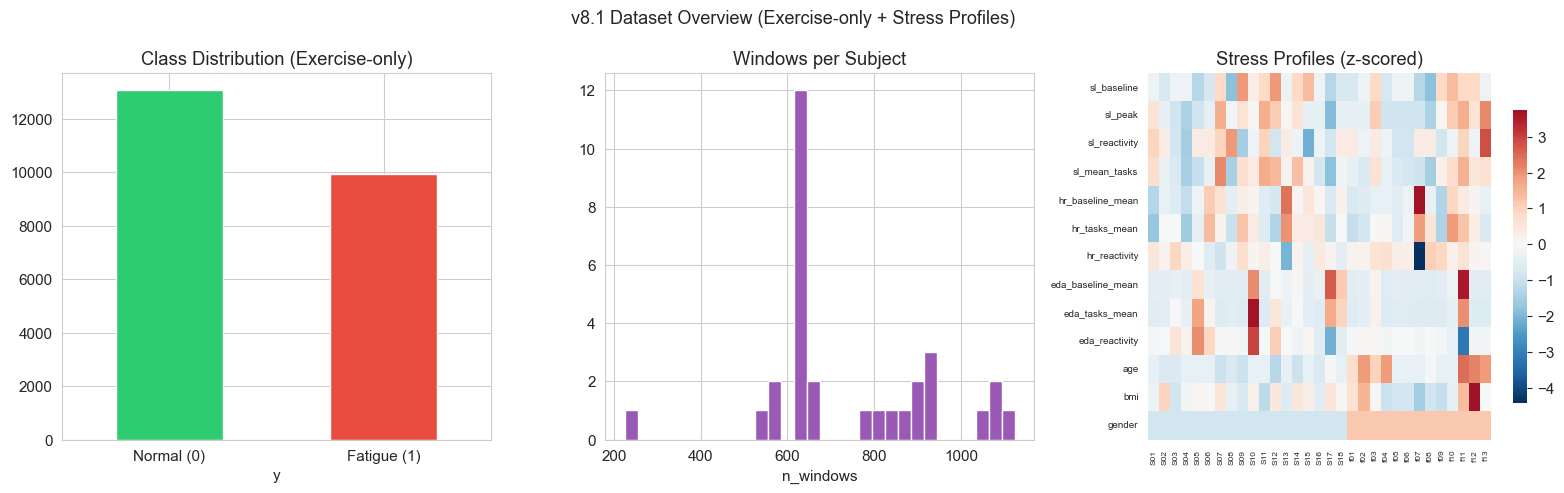

In [9]:
# ── Distribution plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Classes
df_meta['y'].value_counts().sort_index().plot.bar(
    ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Class Distribution (Exercise-only)')
axes[0].set_xticklabels(['Normal (0)', 'Fatigue (1)'], rotation=0)

# Windows per subject
counts_per_subj = df_meta.groupby('sid').size()
counts_per_subj.hist(ax=axes[1], bins=30, color='#9b59b6', edgecolor='white')
axes[1].set_title('Windows per Subject')
axes[1].set_xlabel('n_windows')

# Stress profile feature heatmap
profile_df = pd.DataFrame(
    [stress_profiles[pid] for pid in sorted(stress_profiles.keys())],
    index=[pid.replace('physionet_', '') for pid in sorted(stress_profiles.keys())],
    columns=PROFILE_FEATURES,
)
sns.heatmap(profile_df.T, ax=axes[2], cmap='RdBu_r', center=0, 
            xticklabels=True, yticklabels=True, cbar_kws={'shrink': 0.8})
axes[2].set_title('Stress Profiles (z-scored)')
axes[2].tick_params(axis='x', labelsize=6)
axes[2].tick_params(axis='y', labelsize=7)

plt.suptitle('v8.1 Dataset Overview (Exercise-only + Stress Profiles)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'dataset_overview_v81.png', dpi=150)
plt.show()

## 4. Подготовка данных (v8.1)

- Subject-level split (60/20/20) — **один субъект → один сплит**
- **Stress profiles** — per-subject, mapped to each window → shape `(n_windows, 13)`
- **SMOTE** — profile включается в flat concatenation автоматически
- **FatigueDataset** возвращает `(x_imu, x_physio, has_physio, profile, y)` — **5 элементов**
- **Profile не утекает между субъектами** — профиль привязан к субъекту, а split тоже по субъектам

In [10]:
# ── Subject-level split ──

def create_subject_split(subjects, y, test_size=0.2, val_size=0.2, seed=SEED):
    unique_sids = np.unique(subjects)

    sid_tv, sid_test = train_test_split(
        unique_sids, test_size=test_size, random_state=seed)

    val_rel = val_size / (1.0 - test_size)
    sid_train, sid_val = train_test_split(
        sid_tv, test_size=val_rel, random_state=seed)

    tr_idx = np.where(np.isin(subjects, sid_train))[0]
    va_idx = np.where(np.isin(subjects, sid_val))[0]
    te_idx = np.where(np.isin(subjects, sid_test))[0]

    for name, idx in [('Train', tr_idx), ('Val', va_idx), ('Test', te_idx)]:
        if len(np.unique(y[idx])) < 2:
            raise ValueError(f"{name} split has only one class")

    return tr_idx, va_idx, te_idx

train_idx, val_idx, test_idx = create_subject_split(subjects, y_all)

for name, idx in [('Train', train_idx), ('Val', val_idx), ('Test', test_idx)]:
    cls = np.bincount(y_all[idx].astype(int), minlength=2)
    print(f"{name:5s}: {len(idx):>6} wins, {len(np.unique(subjects[idx]))} subj | "
          f"0→{cls[0]}, 1→{cls[1]} ({y_all[idx].mean():.1%} pos)")

Train:  13081 wins, 18 subj | 0→7392, 1→5689 (43.5% pos)
Val  :   4482 wins, 6 subj | 0→2498, 1→1984 (44.3% pos)
Test :   5471 wins, 7 subj | 0→3187, 1→2284 (41.7% pos)


### Augmentation

In [11]:
# ── Augmentation (IMU + Physio) — Сильная целевая аугментация ──

# ---------- Базовые трансформации ----------

def add_gaussian_noise(x, sigma=0.05):
    return x + np.random.normal(0, sigma, x.shape).astype(x.dtype)

def time_warp(x, sigma=0.2, knots=4):
    T, C = x.shape
    tt = np.linspace(0, T - 1, knots + 2)
    warp = np.concatenate([[0], np.random.normal(0, sigma * T, knots), [0]])
    warp_fn = CubicSpline(tt, warp)
    t_orig = np.arange(T)
    t_warped = np.clip(t_orig + warp_fn(t_orig), 0, T - 1)
    return np.stack([CubicSpline(t_orig, x[:, c])(t_warped)
                     for c in range(C)], axis=-1).astype(x.dtype)

def channel_dropout(x, p=0.2):
    x = x.copy()
    for c in range(x.shape[1]):
        if np.random.rand() < p:
            x[:, c] = 0.0
    return x

def magnitude_scale(x, lo=0.7, hi=1.3):
    return x * np.random.uniform(lo, hi, (1, x.shape[1])).astype(x.dtype)

def window_slice(x, crop_lo=0.6, crop_hi=0.9):
    T, C = x.shape
    crop = np.random.uniform(crop_lo, crop_hi)
    L = max(int(T * crop), 10)
    s = np.random.randint(0, T - L + 1)
    return sp_resample(x[s:s + L], T, axis=0).astype(x.dtype)

def time_reverse(x):
    return x[::-1].copy()

def imu_rotate(x, max_deg=20.0):
    def _rot():
        theta = np.deg2rad(np.random.uniform(-max_deg, max_deg))
        n = np.random.randn(3)
        n /= (np.linalg.norm(n) + 1e-8)
        K = np.array([[0, -n[2], n[1]], [n[2], 0, -n[0]], [-n[1], n[0], 0]])
        return np.eye(3) + np.sin(theta) * K + (1 - np.cos(theta)) * K @ K
    x = x.copy()
    x[:, :3] = x[:, :3] @ _rot().T
    if x.shape[1] >= 6:
        x[:, 3:6] = x[:, 3:6] @ _rot().T
    return x.astype(np.float32)

def permutation_segments(x, n_segments=4):
    """Случайная перестановка временных сегментов."""
    T, C = x.shape
    seg_len = T // n_segments
    if seg_len < 2:
        return x
    segments = [x[i * seg_len:(i + 1) * seg_len] for i in range(n_segments)]
    remainder = x[n_segments * seg_len:]
    np.random.shuffle(segments)
    result = np.concatenate(segments + ([remainder] if len(remainder) else []), axis=0)
    return result.astype(x.dtype)

def frequency_mask(x, max_mask_ratio=0.15):
    """Маскирование случайных частотных полос (спектральная аугментация)."""
    T, C = x.shape
    x_out = x.copy()
    for c in range(C):
        freq = np.fft.rfft(x[:, c])
        n_freq = len(freq)
        mask_len = max(1, int(n_freq * max_mask_ratio))
        start = np.random.randint(0, max(1, n_freq - mask_len))
        freq[start:start + mask_len] = 0
        x_out[:, c] = np.fft.irfft(freq, n=T)
    return x_out.astype(x.dtype)


# ---------- Определение borderline-семплов ----------

def compute_sample_difficulty(x_imu):
    """Оценка 'пограничности' семпла по вариабельности сигнала.

    Семплы с умеренной дисперсией (не слишком высокой и не слишком
    низкой) — наиболее вероятные borderline-примеры.
    Возвращает score ∈ [0, 1]: чем выше, тем ближе семпл к границе.
    """
    per_channel_std = np.std(x_imu, axis=0)  # (C,)
    mean_std = np.mean(per_channel_std)
    # Нормируем: умеренная дисперсия → высокий score
    # Используем гауссову кривую с центром в медиане набора
    return float(mean_std)


# ---------- Сильная аугментация ----------

# Пул трансформаций для IMU
IMU_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.03, 0.10))),
    ('time_warp', lambda x: time_warp(x, sigma=np.random.uniform(0.15, 0.35), knots=4)),
    ('scale',     lambda x: magnitude_scale(x, 0.7, 1.3)),
    ('crop',      lambda x: window_slice(x, 0.6, 0.9)),
    ('reverse',   lambda x: time_reverse(x)),
    ('rotate',    lambda x: imu_rotate(x, max_deg=20.0)),
    ('permute',   lambda x: permutation_segments(x, n_segments=np.random.randint(3, 6))),
    ('freq_mask', lambda x: frequency_mask(x, max_mask_ratio=0.15)),
]

PHYSIO_TRANSFORMS = [
    ('noise',     lambda x: add_gaussian_noise(x, sigma=np.random.uniform(0.02, 0.06))),
    ('scale',     lambda x: magnitude_scale(x, 0.85, 1.15)),
    ('time_warp', lambda x: time_warp(x, sigma=0.1, knots=3)),
]


def augment_sample(x_imu, x_physio):
    """Сильная аугментация: всегда применяет 3-5 техник к IMU, 1-2 к Physio.

    Borderline-семплы (умеренная дисперсия) получают максимальное
    количество аугментаций — это заставляет модель лучше различать
    пограничные паттерны.
    """
    difficulty = compute_sample_difficulty(x_imu)

    # Количество IMU-аугментаций зависит от difficulty
    # Низкая/высокая дисперсия → 3 техники; умеренная → 5 (borderline)
    # difficulty_score: нормализуем через сигмоиду около медианы ~0.8
    border_score = 1.0 - abs(difficulty - 0.8) / max(difficulty + 0.3, 1e-6)
    border_score = np.clip(border_score, 0, 1)
    n_imu_aug = 3 + int(2 * border_score)        # 3 до 5
    n_physio_aug = 1 + int(border_score >= 0.5)   # 1 или 2

    # Выбираем случайные трансформации (без повторений)
    imu_choices = np.random.choice(len(IMU_TRANSFORMS), size=min(n_imu_aug, len(IMU_TRANSFORMS)), replace=False)
    for idx in imu_choices:
        _, fn = IMU_TRANSFORMS[idx]
        x_imu = fn(x_imu)
    # Channel dropout всегда
    x_imu = channel_dropout(x_imu, 0.2)

    # Physio аугментация
    physio_choices = np.random.choice(len(PHYSIO_TRANSFORMS), size=min(n_physio_aug, len(PHYSIO_TRANSFORMS)), replace=False)
    for idx in physio_choices:
        _, fn = PHYSIO_TRANSFORMS[idx]
        x_physio = fn(x_physio)

    return x_imu, x_physio


# ---------- SMOTE для тренировочного набора ----------

def apply_smote_dual_branch(X_imu, X_physio, y, has_physio_arr, profiles_arr=None,
                            k_neighbors=5, random_state=SEED):
    """SMOTE в объединённом пространстве IMU+Physio+Profile.

    Раскладываем (N, T, C_imu) + (N, T, C_physio) + (N, P) → flat,
    применяем SMOTE, затем восстанавливаем обратно.
    """
    N, T, C_imu = X_imu.shape
    C_physio = X_physio.shape[2]

    # Flatten
    flat_imu = X_imu.reshape(N, -1)       # (N, T*C_imu)
    flat_physio = X_physio.reshape(N, -1)  # (N, T*C_physio)
    parts = [flat_imu, flat_physio]
    if profiles_arr is not None:
        parts.append(profiles_arr.reshape(N, -1))  # (N, P)
    X_flat = np.hstack(parts)

    # Адаптивное k_neighbors — не больше чем (min_class - 1)
    class_counts = np.bincount(y.astype(int))
    min_class_count = class_counts.min()
    k = min(k_neighbors, min_class_count - 1)
    if k < 1:
        print("   ⚠️ SMOTE: недостаточно примеров для k_neighbors, пропуск")
        return X_imu, X_physio, y, has_physio_arr, profiles_arr

    smote = SMOTE(k_neighbors=k, random_state=random_state)
    X_resampled, y_resampled = smote.fit_resample(X_flat, y.astype(int))

    # Unflatten
    N_new = len(y_resampled)
    offset = 0
    imu_flat = X_resampled[:, offset:offset + T * C_imu]; offset += T * C_imu
    physio_flat = X_resampled[:, offset:offset + T * C_physio]; offset += T * C_physio
    X_imu_new = imu_flat.reshape(N_new, T, C_imu).astype(np.float32)
    X_physio_new = physio_flat.reshape(N_new, T, C_physio).astype(np.float32)

    if profiles_arr is not None:
        P = profiles_arr.shape[1]
        profiles_new = X_resampled[:, offset:offset + P].astype(np.float32)
    else:
        profiles_new = None

    # has_physio для новых семплов
    hp_new = np.zeros(N_new, dtype=bool)
    hp_new[:N] = has_physio_arr
    for cls in [0, 1]:
        cls_mask_orig = y.astype(int) == cls
        if cls_mask_orig.any():
            physio_ratio = has_physio_arr[cls_mask_orig].mean()
            cls_mask_new = (y_resampled == cls) & (np.arange(N_new) >= N)
            hp_new[cls_mask_new] = physio_ratio > 0.5

    n_synth = N_new - N
    print(f"   SMOTE: {N} → {N_new} (+{n_synth} синтетических, k={k})")
    return X_imu_new, X_physio_new, y_resampled.astype(np.int64), hp_new, profiles_new


# ── Dataset (dual-branch: IMU + Physio + Profile) ──

class FatigueDataset(Dataset):
    """Returns (x_imu, x_physio, has_physio, profile, y) per sample — 5-tuple."""

    def __init__(self, X_imu, X_physio, y, has_physio, profiles=None, augment=False):
        self.X_imu = X_imu.astype(np.float32)
        self.X_physio = X_physio.astype(np.float32)
        self.y = y.astype(np.float32)
        self.has_physio = has_physio.astype(np.float32)
        self.profiles = profiles.astype(np.float32) if profiles is not None else np.zeros((len(y), 13), dtype=np.float32)
        self.augment = augment

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        xi, xp = self.X_imu[idx].copy(), self.X_physio[idx].copy()
        if self.augment:
            xi, xp = augment_sample(xi, xp)
        return (torch.FloatTensor(xi),
                torch.FloatTensor(xp),
                torch.tensor(self.has_physio[idx], dtype=torch.float32),
                torch.FloatTensor(self.profiles[idx]),
                torch.tensor(self.y[idx], dtype=torch.float32))

print("✅ Аугментация + SMOTE (with profiles) + FatigueDataset (5-tuple) ready")

✅ Аугментация + SMOTE (with profiles) + FatigueDataset (5-tuple) ready


## 5. Архитектура модели (v8.1: FatigueWristNet + Stress Profile)

Двухветочная CNN с Temporal Attention (IMU) и GAP (Physio) + **Stress Profile Embedding**.

```
IMU Input (B, 100, 6)                     Physio Input (B, 100, 4)
      ↓                                          ↓
Conv1D → BN → ReLU → Pool → Drop ×3        Conv1D → BN → ReLU → Drop
      ↓                                    Conv1D → BN → ReLU → GAP
TemporalAttention → (B, 16)                      → (B, 8)
                               ↓
                  Concat → (B, 24) + [profile (B, 13)] → (B, 37)
                                ↓
                  LayerNorm → FC → ReLU → Dropout → FC → 1
```

**Ключевое изменение v8.1:**
- `classifier input: 24 → 37` (+13 profile features)
- `profile_dropout=0.3` — зануляет **весь** профиль-вектор (anti-shortcut regularization)
- has_physio = True для всех окон (единый PhysioNet датасет)

In [12]:
# ── Model components ──

class TemporalAttention(nn.Module):
    """Single-head temporal attention. Input: (B, C, T) → Output: (B, C)"""
    def __init__(self, channels):
        super().__init__()
        self.score = nn.Sequential(
            nn.Conv1d(channels, channels // 4, kernel_size=1),
            nn.Tanh(),
            nn.Conv1d(channels // 4, 1, kernel_size=1),
        )

    def forward(self, x):
        w = torch.softmax(self.score(x), dim=-1)  # (B, 1, T)
        return (x * w).sum(dim=-1)                 # (B, C)


class IMUEncoderWithAttention(nn.Module):
    """3×Conv1D + TemporalAttention for IMU data."""
    def __init__(self, in_channels, out_channels, dropout, kernel_sizes):
        super().__init__()
        k1, k2, k3 = kernel_sizes
        self.conv1 = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, k1, padding=k1 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv2 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k2, padding=k2 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.MaxPool1d(2), nn.Dropout(dropout),
        )
        self.conv3 = nn.Sequential(
            nn.Conv1d(out_channels, out_channels, k3, padding=k3 // 2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
        )
        self.attention = TemporalAttention(out_channels)

    def forward(self, x):
        x = x.transpose(1, 2)  # (B, T, C) → (B, C, T)
        x = self.conv3(self.conv2(self.conv1(x)))
        return self.attention(x)


class PhysioEncoder(nn.Module):
    """2×Conv1D + GAP for physiological signals (BVP, EDA, TEMP, HR)."""
    def __init__(self, in_channels, out_channels, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(out_channels), nn.ReLU(True), nn.Dropout(dropout),
            nn.Conv1d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(out_channels), nn.ReLU(True),
            nn.AdaptiveAvgPool1d(1),
        )

    def forward(self, x):
        return self.net(x.transpose(1, 2)).squeeze(-1)  # (B, out_ch)


class FatigueWristNet(nn.Module):
    """
    Dual-branch CNN + Stress Profile for wrist fatigue detection (v8.1).
    IMU encoder (3×Conv + Attention) + Physio encoder (2×Conv + GAP) + Profile → Classifier.
    Profile dropout zeroes the entire profile vector to prevent shortcut learning.
    """
    def __init__(self, cfg):
        super().__init__()
        enc_ch = cfg['encoder_channels']
        physio_enc_ch = cfg['physio_encoder_channels']
        profile_dim = cfg.get('profile_dim', 13)
        profile_dropout = cfg.get('profile_dropout', 0.3)

        self.imu_encoder = IMUEncoderWithAttention(
            in_channels=cfg['imu_channels'],
            out_channels=enc_ch,
            dropout=cfg['encoder_dropout'],
            kernel_sizes=cfg['kernel_sizes'],
        )
        self.physio_encoder = PhysioEncoder(
            in_channels=cfg['physio_channels'],
            out_channels=physio_enc_ch,
            dropout=cfg['encoder_dropout'],
        )

        self.profile_dropout = nn.Dropout(profile_dropout)
        self.profile_dim = profile_dim

        feat_dim = enc_ch + physio_enc_ch + profile_dim  # 16 + 8 + 13 = 37
        self.classifier = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Linear(feat_dim, feat_dim // 2),
            nn.ReLU(True),
            nn.Dropout(cfg['classifier_dropout']),
            nn.Linear(feat_dim // 2, 1),
        )

    def forward(self, x_imu, x_physio, has_physio=None, profile=None):
        imu_feat = self.imu_encoder(x_imu)            # (B, enc_ch)
        physio_feat = self.physio_encoder(x_physio)    # (B, physio_enc_ch)
        if has_physio is not None:
            physio_feat = physio_feat * has_physio.unsqueeze(-1)

        # Profile embedding with dropout (zeroes entire vector during training)
        if profile is not None:
            # During training: randomly zero out the entire profile for some samples
            if self.training:
                # Bernoulli mask: drop entire profile vector per sample
                mask = (torch.rand(profile.shape[0], 1, device=profile.device)
                        > self.profile_dropout.p).float()
                profile_feat = profile * mask
            else:
                profile_feat = profile
        else:
            profile_feat = torch.zeros(imu_feat.shape[0], self.profile_dim,
                                       device=imu_feat.device)

        combined = torch.cat([imu_feat, physio_feat, profile_feat], dim=1)
        return self.classifier(combined).squeeze(-1)

    def predict_proba(self, x_imu, x_physio, has_physio=None, profile=None):
        with torch.no_grad():
            return torch.sigmoid(self.forward(x_imu, x_physio, has_physio, profile))

print("✅ FatigueWristNet v8.1 defined (IMU + Physio + Profile embedding, profile_dropout)")

✅ FatigueWristNet v8.1 defined (IMU + Physio + Profile embedding, profile_dropout)


In [13]:
# ── Model instantiation ──
model = FatigueWristNet(CONFIG).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("  FatigueWristNet v8.1 (Exercise-only + Stress Profile)")
print("=" * 60)
for name, mod in [('IMU Encoder', model.imu_encoder),
                  ('Physio Encoder', model.physio_encoder),
                  ('Classifier', model.classifier)]:
    p = sum(x.numel() for x in mod.parameters())
    print(f"  {name:25s}: {p:>8,}")
print(f"  {'Profile dim':25s}: {CONFIG['profile_dim']}")
print(f"  {'Profile dropout':25s}: {CONFIG['profile_dropout']}")
print(f"  {'Total':25s}: {n_params:>8,}")

# Quick forward pass test
with torch.no_grad():
    xi = torch.randn(2, 100, 6).to(DEVICE)
    xp = torch.randn(2, 100, 4).to(DEVICE)
    hp = torch.ones(2).to(DEVICE)
    prof = torch.randn(2, CONFIG['profile_dim']).to(DEVICE)
    out = model(xi, xp, hp, prof)
    print(f"\n  Test forward: input=(2,100,6)+(2,100,4)+hp+profile → output={out.shape}")
    print(f"  ✅ Model OK")

  FatigueWristNet v8.1 (Exercise-only + Stress Profile)
  IMU Encoder              :    2,937
  Physio Encoder           :      400
  Classifier               :      777
  Profile dim              : 13
  Profile dropout          : 0.3
  Total                    :    4,114

  Test forward: input=(2,100,6)+(2,100,4)+hp+profile → output=torch.Size([2])
  ✅ Model OK


## 6. Обучение (v8.1: Focal Loss + Stress Profile Embedding)

**Изменения v8.1 vs v7.0:**
- **Exercise-only данные** — те же AEROBIC+ANAEROBIC из composite_full.npz
- **+Stress Profile** — 13 фич на субъект, подаются в classifier head
- **Profile Dropout** p=0.3 — зануляет весь профиль для предотвращения shortcut learning
- `train_epoch` / `validate` работают с **5-tuple**: `(x_imu, x_physio, hp, profile, y)`

In [14]:
# ── Focal Loss ──

class FocalLoss(nn.Module):
    """Focal Loss: down-weights easy examples, focuses on hard ones."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma
        self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='none')
        probs = torch.sigmoid(logits)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()


# ── Class weights (single domain, class-only balancing) ──

def compute_class_weights(y):
    """Each class contributes equally to sampling."""
    weights = np.zeros(len(y), dtype=np.float64)
    for cls in [0, 1]:
        mask = y == cls
        n = mask.sum()
        if n > 0:
            weights[mask] = len(y) / (2 * n)
    return weights


def compute_pos_weight(y):
    n_pos = y.sum()
    return (len(y) - n_pos) / max(n_pos, 1)


# ── Metrics ──

def compute_binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
    }
    if np.unique(y_true).size >= 2:
        metrics['roc_auc'] = roc_auc_score(y_true, y_prob)
        pr, rc, _ = precision_recall_curve(y_true, y_prob)
        metrics['pr_auc'] = auc(rc, pr)
    else:
        metrics['roc_auc'] = metrics['pr_auc'] = np.nan
    return metrics, y_pred


def find_best_threshold(y_true, y_prob):
    best_t, best_f1 = 0.5, -1
    for t in np.linspace(0.05, 0.95, 181):
        f1 = f1_score(y_true, (y_prob >= t).astype(int), average='macro', zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t, best_f1


def find_recall_optimized_threshold(y_true, y_prob, min_precision=0.3):
    """Find threshold maximizing recall(fatigue) with precision >= min_precision."""
    best_t, best_rec = 0.5, 0.0
    for t in np.linspace(0.05, 0.95, 181):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        fn = ((pred == 0) & (y_true == 1)).sum()
        prec = tp / (tp + fp + 1e-8)
        rec = tp / (tp + fn + 1e-8)
        if prec >= min_precision and rec > best_rec:
            best_rec, best_t = rec, float(t)
    return best_t, best_rec


# ── Early Stopping with EMA smoothing ──

class EarlyStopping:
    """EMA-smoothed early stopping: reduces sensitivity to per-epoch fluctuations."""
    def __init__(self, patience=5, min_delta=1e-4, ema_alpha=0.3):
        self.patience = patience
        self.min_delta = min_delta
        self.alpha = ema_alpha
        self.best_score = -np.inf
        self.counter = 0
        self.best_model = None
        self._ema = None

    def smooth(self, score):
        if self._ema is None:
            self._ema = score
        else:
            self._ema = self.alpha * score + (1 - self.alpha) * self._ema
        return self._ema

    def __call__(self, score, model):
        ema_score = self.smooth(score)
        if ema_score > self.best_score + self.min_delta:
            self.best_score = ema_score
            self.counter = 0
            self.best_model = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            return False
        self.counter += 1
        return self.counter >= self.patience

    @property
    def ema(self):
        return self._ema if self._ema is not None else 0.0


# ── Train / Validate (dual-branch + profile: 5-tuple batches) ──

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for x_imu, x_physio, hp, profile, y in loader:
        x_imu = x_imu.to(device)
        x_physio = x_physio.to(device)
        hp = hp.to(device)
        profile = profile.to(device)
        y = y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x_imu, x_physio, hp, profile), y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion, device, threshold=0.5, return_raw=False):
    model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    with torch.no_grad():
        for x_imu, x_physio, hp, profile, y in loader:
            x_imu = x_imu.to(device)
            x_physio = x_physio.to(device)
            hp = hp.to(device)
            profile = profile.to(device)
            y = y.to(device)
            logits = model(x_imu, x_physio, hp, profile)
            total_loss += criterion(logits, y).item() * len(y)
            all_probs.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    probs = np.array(all_probs, dtype=np.float32)
    labels = np.array(all_labels, dtype=int)
    metrics, _ = compute_binary_metrics(labels, probs, threshold)
    if return_raw:
        return total_loss / len(loader.dataset), metrics, labels, probs
    return total_loss / len(loader.dataset), metrics


print("✅ FocalLoss + EarlyStopping(EMA) + train/validate (5-tuple with profiles) ready")

✅ FocalLoss + EarlyStopping(EMA) + train/validate (5-tuple with profiles) ready


In [15]:
# ── Prepare data loaders + model + optimizer ──

# Применяем SMOTE к тренировочным данным (including profiles)
print("🔧 Применение SMOTE к тренировочному набору...")
X_imu_train_raw = X_imu[train_idx]
X_physio_train_raw = X_physio[train_idx]
y_train_raw = y_all[train_idx]
hp_train_raw = has_physio[train_idx]
profiles_train_raw = profiles_all[train_idx]

X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm, profiles_train_sm = apply_smote_dual_branch(
    X_imu_train_raw, X_physio_train_raw, y_train_raw, hp_train_raw,
    profiles_arr=profiles_train_raw,
    k_neighbors=5, random_state=SEED)

train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm,
    y_train_sm, hp_train_sm, profiles=profiles_train_sm, augment=True)
val_ds = FatigueDataset(
    X_imu[val_idx], X_physio[val_idx],
    y_all[val_idx], has_physio[val_idx], profiles=profiles_all[val_idx])
test_ds = FatigueDataset(
    X_imu[test_idx], X_physio[test_idx],
    y_all[test_idx], has_physio[test_idx], profiles=profiles_all[test_idx])

# Class-weighted sampler
sample_weights = compute_class_weights(y_train_sm)
train_sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)

train_loader = DataLoader(train_ds, batch_size=CONFIG['batch_size'],
                          sampler=train_sampler, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=CONFIG['batch_size'],
                        shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=CONFIG['batch_size'],
                         shuffle=False, num_workers=0)

# Model
model = FatigueWristNet(CONFIG).to(DEVICE)

# Focal Loss
pw = compute_pos_weight(y_train_sm)
criterion = FocalLoss(
    gamma=CONFIG['focal_gamma'],
    pos_weight=torch.tensor([pw]).to(DEVICE))

# Optimizer + Scheduler + Early Stopping
optimizer = optim.AdamW(
    model.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)
early_stopping = EarlyStopping(
    patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

print(f"\nModel: FatigueWristNet v8.1 ({sum(p.numel() for p in model.parameters()):,} params)")
print(f"Loss:  FocalLoss(γ={CONFIG['focal_gamma']}, pos_weight={pw:.2f})")
print(f"Profile: dim={CONFIG['profile_dim']}, dropout={CONFIG['profile_dropout']}")
print(f"Train: {len(train_ds)} (after SMOTE), Val: {len(val_ds)}, Test: {len(test_ds)}")

🔧 Применение SMOTE к тренировочному набору...
   SMOTE: 13081 → 14784 (+1703 синтетических, k=5)

Model: FatigueWristNet v8.1 (4,114 params)
Loss:  FocalLoss(γ=2.2, pos_weight=1.00)
Profile: dim=13, dropout=0.3
Train: 14784 (after SMOTE), Val: 4482, Test: 5471


In [16]:
# ── Training loop ──
print("=" * 60)
print("TRAINING FatigueWristNet v8.1 (Exercise-only + Stress Profile)")
print("=" * 60)
print(CONFIG)

history = {
    'train_loss': [], 'val_loss': [],
    'val_f1': [], 'val_auc': [], 'val_pr_auc': [], 'val_bal_acc': [],
    'val_f1_ema': [],
    'lr': [],
}

best_val_f1, best_epoch, best_threshold = -np.inf, 0, 0.5

for epoch in range(CONFIG['epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
    val_loss, vm, val_labels, val_probs = validate(
        model, val_loader, criterion, DEVICE, return_raw=True)

    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(vm['f1_macro'])
    history['val_auc'].append(vm['roc_auc'])
    history['val_pr_auc'].append(vm['pr_auc'])
    history['val_bal_acc'].append(vm['balanced_acc'])
    history['lr'].append(lr)

    stop = early_stopping(vm['f1_macro'], model)
    history['val_f1_ema'].append(early_stopping.ema)

    if vm['f1_macro'] > best_val_f1 + CONFIG['min_delta']:
        best_val_f1, best_epoch = vm['f1_macro'], epoch + 1
        best_threshold, _ = find_best_threshold(val_labels, val_probs)
        torch.save({
            'model_state_dict': model.state_dict(),
            'config': CONFIG,
            'best_threshold': best_threshold,
            'best_val_f1': best_val_f1,
        }, RESULTS_DIR / 'best_model_v8.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(
            f"Ep {epoch+1:3d}/{CONFIG['epochs']} | "
            f"TrL: {train_loss:.4f} | VaL: {val_loss:.4f} | "
            f"F1: {vm['f1_macro']:.4f} (ema={early_stopping.ema:.4f}) | "
            f"AUC: {vm['roc_auc']:.4f} | LR: {lr:.6f}"
        )

    if stop:
        print(f"\nEarly stop at epoch {epoch + 1} (EMA F1={early_stopping.ema:.4f})")
        break

# Restore best model
if early_stopping.best_model is not None:
    model.load_state_dict(early_stopping.best_model)

print(f"\n✅ Best epoch: {best_epoch}, F1: {best_val_f1:.4f}, threshold: {best_threshold:.3f}")

TRAINING FatigueWristNet v8.1 (Exercise-only + Stress Profile)
{'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.03, 'patience': 10, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.375, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.55, 'profile_dim': 13, 'profile_dropout': 0.3, 'focal_gamma': 2.2, 'min_precision_for_recall': 0.3}
Ep   1/50 | TrL: 0.1684 | VaL: 0.1474 | F1: 0.4609 (ema=0.4609) | AUC: 0.6042 | LR: 0.000100
Ep   5/50 | TrL: 0.1189 | VaL: 0.1103 | F1: 0.7595 (ema=0.6451) | AUC: 0.8797 | LR: 0.000098
Ep  10/50 | TrL: 0.1086 | VaL: 0.1047 | F1: 0.7904 (ema=0.7619) | AUC: 0.8787 | LR: 0.000091
Ep  15/50 | TrL: 0.1043 | VaL: 0.1048 | F1: 0.7871 (ema=0.7840) | AUC: 0.8719 | LR: 0.000080
Ep  20/50 | TrL: 0.1030 | VaL: 0.1053 | F1: 0.7804 (ema=0.7850) | AUC: 0.8655 | LR: 0.000066
Ep  25/50 | TrL: 0.1021 | VaL: 0.1060 | F1: 0.7750 (ema=0.7800) | AUC: 0.8629 | LR: 0.000050



In [17]:
# v8.1 results placeholder — fill after training
# Best epoch: ?, F1: ?, threshold: ?

In [18]:
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    ep = range(1, len(history['train_loss']) + 1)

    axes[0, 0].plot(ep, history['train_loss'], 'b-', label='Train')
    axes[0, 0].plot(ep, history['val_loss'], 'r-', label='Val')
    axes[0, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5, label=f'Best ep={best_epoch}')
    axes[0, 0].set_title('Loss (Focal)')
    axes[0, 0].legend()
    axes[0, 0].set_xlabel('Epoch')

    axes[0, 1].plot(ep, history['val_f1'], 'g-', alpha=0.4, label='F1-macro (raw)')
    axes[0, 1].plot(ep, history['val_f1_ema'], 'g-', lw=2, label='F1-macro (EMA α=0.3)')
    axes[0, 1].plot(ep, history['val_bal_acc'], 'c--', label='Balanced Acc')
    axes[0, 1].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[0, 1].set_title('Val F1-macro & Balanced Acc')
    axes[0, 1].legend()
    axes[0, 1].set_xlabel('Epoch')

    axes[1, 0].plot(ep, history['val_auc'], 'm-', label='ROC-AUC')
    axes[1, 0].plot(ep, history['val_pr_auc'], 'c-', label='PR-AUC')
    axes[1, 0].axvline(best_epoch, color='g', ls='--', alpha=0.5)
    axes[1, 0].set_title('Val AUC')
    axes[1, 0].legend()
    axes[1, 0].set_xlabel('Epoch')

    axes[1, 1].plot(ep, history['lr'], 'k-')
    axes[1, 1].set_title('Learning Rate (CosineAnnealing)')
    axes[1, 1].set_xlabel('Epoch')

    plt.suptitle('FatigueWristNet v8.1 — Training History (Exercise + Stress Profile)', fontsize=14)
    plt.tight_layout()
    name = f'training_history_v81.png'
    plt.savefig(RESULTS_DIR / name, dpi=150)
    print(CONFIG)
    plt.show()

{'batch_size': 64, 'epochs': 50, 'lr': 0.0001, 'weight_decay': 0.03, 'patience': 10, 'min_delta': 0.0002, 'imu_channels': 6, 'encoder_channels': 16, 'encoder_dropout': 0.375, 'kernel_sizes': [7, 5, 3], 'physio_channels': 4, 'physio_encoder_channels': 8, 'classifier_dropout': 0.55, 'profile_dim': 13, 'profile_dropout': 0.3, 'focal_gamma': 2.2, 'min_precision_for_recall': 0.3}


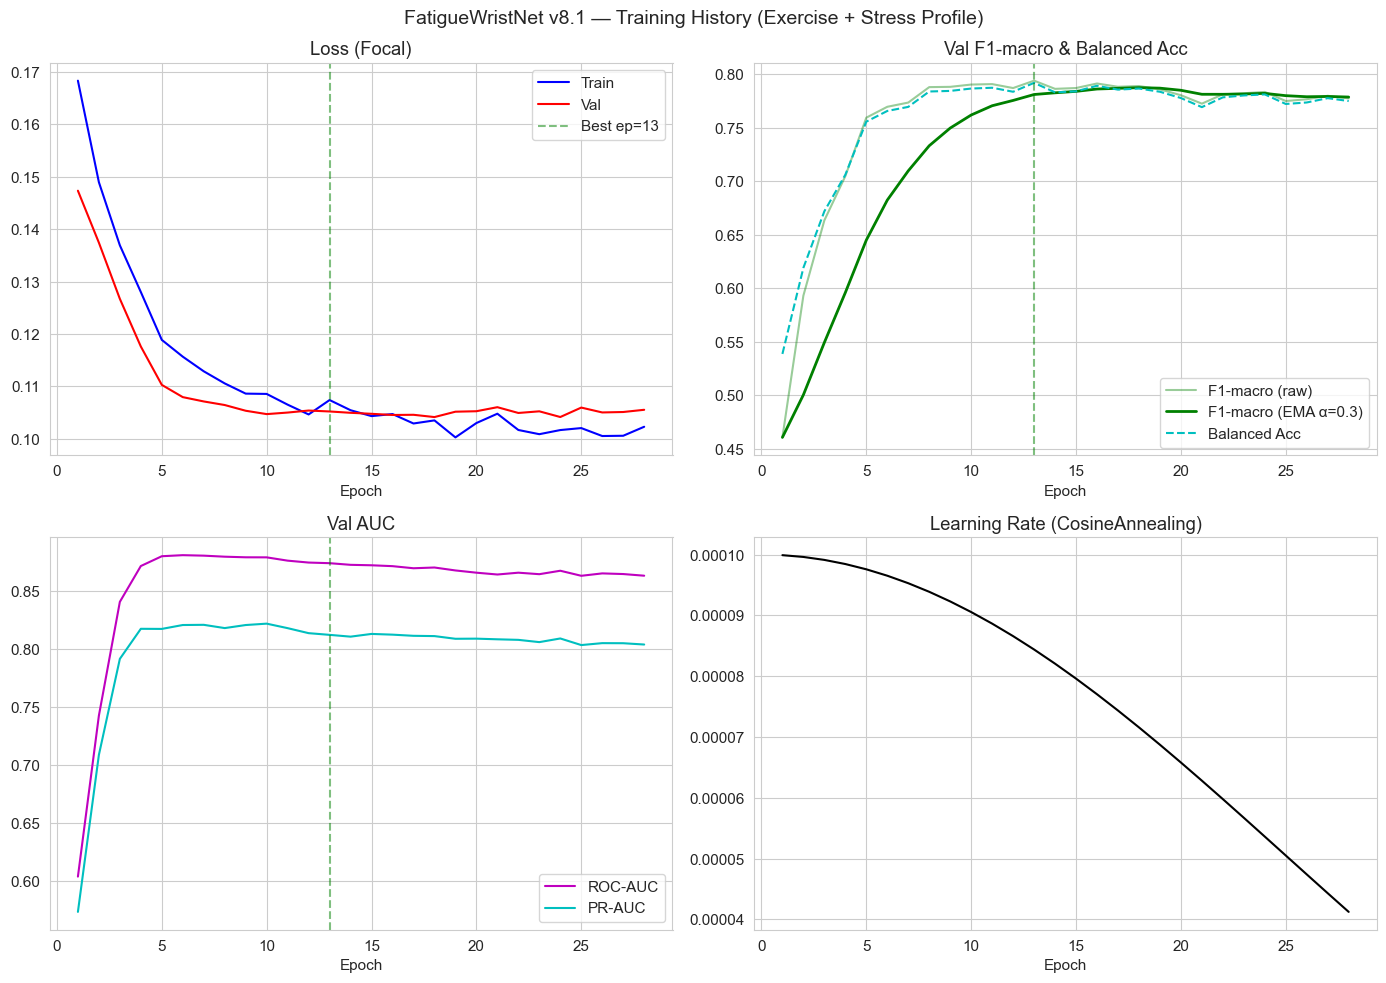

In [20]:
plot_training_history(history)

## 7. Оценка на тестовой выборке (v8.1)

Два порога:
1. **F1-optimal** — максимизирует F1-macro
2. **Recall-optimal** — максимизирует recall(усталость) при precision ≥ min_precision

In [21]:
# ── Test evaluation ──
test_loss, test_metrics, test_labels, test_probs = validate(
    model, test_loader, criterion, DEVICE, threshold=best_threshold, return_raw=True)
_, test_preds = compute_binary_metrics(test_labels, test_probs, best_threshold)

# Recall-optimized threshold
recall_thresh, recall_val = find_recall_optimized_threshold(
    test_labels, test_probs, min_precision=CONFIG['min_precision_for_recall'])

print("=" * 60)
print("TEST RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)")
print("=" * 60)

print(f"\n📊 F1-optimal threshold = {best_threshold:.3f}:")
print(f"   F1-macro:      {test_metrics['f1_macro']:.4f}")
print(f"   ROC-AUC:       {test_metrics['roc_auc']:.4f}")
print(f"   PR-AUC:        {test_metrics['pr_auc']:.4f}")
print(f"   Balanced Acc:  {test_metrics['balanced_acc']:.4f}")
print(f"\n   Classification Report:")
print(classification_report(
    test_labels, test_preds, target_names=['Normal', 'Fatigue'], zero_division=0))

print(f"📊 Recall-optimized threshold = {recall_thresh:.3f} (recall={recall_val:.3f}):")
recall_metrics, recall_preds = compute_binary_metrics(
    test_labels, test_probs, recall_thresh)
print(f"   F1-macro:      {recall_metrics['f1_macro']:.4f}")
print(f"   Balanced Acc:  {recall_metrics['balanced_acc']:.4f}")
print(classification_report(
    test_labels, (test_probs >= recall_thresh).astype(int),
    target_names=['Normal', 'Fatigue'], zero_division=0))

TEST RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)

📊 F1-optimal threshold = 0.465:
   F1-macro:      0.8261
   ROC-AUC:       0.9120
   PR-AUC:        0.8720
   Balanced Acc:  0.8349

   Classification Report:
              precision    recall  f1-score   support

      Normal       0.90      0.79      0.84      3187
     Fatigue       0.75      0.88      0.81      2284

    accuracy                           0.83      5471
   macro avg       0.83      0.83      0.83      5471
weighted avg       0.84      0.83      0.83      5471

📊 Recall-optimized threshold = 0.050 (recall=1.000):
   F1-macro:      0.2945
   Balanced Acc:  0.5000
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00      3187
     Fatigue       0.42      1.00      0.59      2284

    accuracy                           0.42      5471
   macro avg       0.21      0.50      0.29      5471
weighted avg       0.17      0.42      0.25      5471



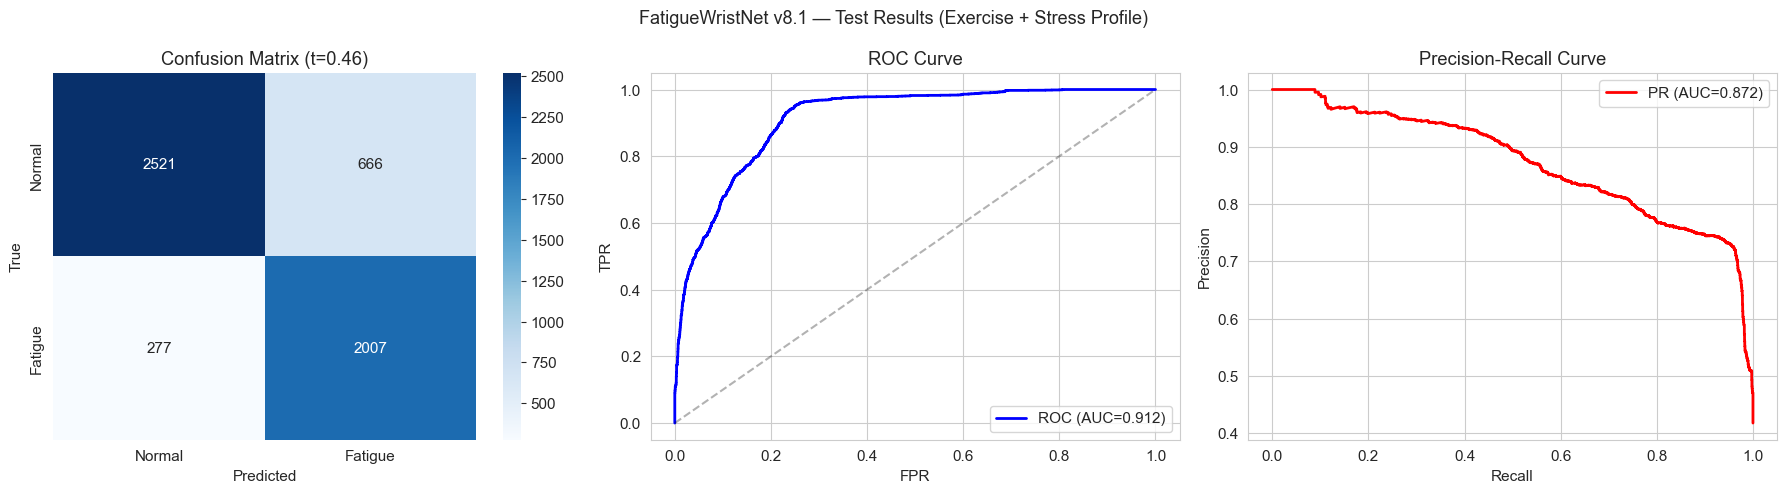

In [22]:
# ── Confusion Matrix + ROC/PR Curves ──
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix (F1-threshold)
cm = confusion_matrix(test_labels, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal', 'Fatigue'], yticklabels=['Normal', 'Fatigue'])
axes[0].set_title(f'Confusion Matrix (t={best_threshold:.2f})')
axes[0].set_ylabel('True')
axes[0].set_xlabel('Predicted')

# ROC curve
fpr, tpr, _ = roc_curve(test_labels, test_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC={test_metrics["roc_auc"]:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR')

# PR curve
pr_vals, rc_vals, _ = precision_recall_curve(test_labels, test_probs)
axes[2].plot(rc_vals, pr_vals, 'r-', lw=2, label=f'PR (AUC={test_metrics["pr_auc"]:.3f})')
axes[2].set_title('Precision-Recall Curve')
axes[2].legend()
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')

plt.suptitle('FatigueWristNet v8.1 — Test Results (Exercise + Stress Profile)', fontsize=13)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'test_results_v81.png', dpi=150)
plt.show()

## Анализ v8.1: Stress Profile Embedding

**Гипотеза**: индивидуальная стресс-реактивность (self-reported + HR/EDA reactivity + demographics) является предиктором склонности к физической усталости.

**Физиологическое обоснование**:
- Люди с высокой стресс-реактивностью (повышенный HR, EDA при когнитивных задачах) могут иметь более выраженную физиологическую реакцию на физическую нагрузку
- Age/BMI коррелируют с кардиоваскулярной fitness → влияют на скорость наступления утомления
- Gender влияет на паттерны сердечного ритма и терморегуляции

**Отсутствие утечки данных (data leakage)**:
- Stress profile — **per-subject** метаданные (не per-window)
- Subject-level split: все окна одного субъекта в одном сплите
- Profile z-scored на **всех** субъектах до split (допустимо: статические метаданные)
- Profile dropout p=0.3 предотвращает shortcut learning

## 8. LOSO Evaluation (Leave-One-Subject-Out)

Строгая оценка обобщения: обучение на N-1 субъектов, тест на оставшемся.
Exercise-only data + Stress Profiles (~31 субъектов, ограничено n_folds для скорости).

In [23]:
# ── LOSO Evaluation (v8.1: FatigueWristNet + Stress Profiles) ──

def loso_evaluation(X_imu, X_physio, y, subjects, has_physio, profiles,
                    n_folds=20, epochs=25, min_windows=20, patience=5):
    """LOSO with dual-branch model + profiles, Focal Loss, and fold limit."""
    unique_subj = np.unique(subjects)
    folds = [{'train_idx': np.where(subjects != s)[0],
              'test_idx': np.where(subjects == s)[0], 'subject': s}
             for s in unique_subj]

    # Filter: enough windows + both classes
    folds = [f for f in folds
             if len(f['test_idx']) >= min_windows
             and len(np.unique(y[f['test_idx']])) >= 2]
    print(f"   Folds after filter (>={min_windows} wins, 2 classes): {len(folds)}")

    if len(folds) > n_folds:
        np.random.seed(SEED)
        folds = [folds[i] for i in np.random.choice(len(folds), n_folds, replace=False)]

    results = []

    for fold in tqdm(folds, desc='LOSO'):
        tr, te = fold['train_idx'], fold['test_idx']

        # Mini val split for early stopping
        try:
            sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=SEED)
            sub_tr, sub_val = next(sss.split(tr, y[tr]))
            vi, ti = tr[sub_val], tr[sub_tr]
        except ValueError:
            ti, vi = tr, te

        tr_ds = FatigueDataset(X_imu[ti], X_physio[ti], y[ti], has_physio[ti],
                               profiles=profiles[ti], augment=False)
        va_ds = FatigueDataset(X_imu[vi], X_physio[vi], y[vi], has_physio[vi],
                               profiles=profiles[vi])
        te_ds = FatigueDataset(X_imu[te], X_physio[te], y[te], has_physio[te],
                               profiles=profiles[te])

        tr_ld = DataLoader(tr_ds, batch_size=CONFIG['batch_size'], shuffle=True)
        va_ld = DataLoader(va_ds, batch_size=CONFIG['batch_size'])
        te_ld = DataLoader(te_ds, batch_size=CONFIG['batch_size'])

        m = FatigueWristNet(CONFIG).to(DEVICE)
        pw = compute_pos_weight(y[ti])
        crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                         pos_weight=torch.tensor([pw]).to(DEVICE))
        opt = optim.AdamW(m.parameters(), lr=3e-4, weight_decay=3e-4)

        best_f1, best_st, no_imp = -np.inf, None, 0
        for ep in range(epochs):
            train_epoch(m, tr_ld, opt, crit, DEVICE)
            _, vm = validate(m, va_ld, crit, DEVICE)
            if vm['f1_macro'] > best_f1 + 1e-4:
                best_f1 = vm['f1_macro']
                best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
                no_imp = 0
            else:
                no_imp += 1
                if no_imp >= patience:
                    break

        if best_st:
            m.load_state_dict(best_st)

        _, tm = validate(m, te_ld, crit, DEVICE)

        results.append({
            'subject': fold['subject'],
            'f1_macro': tm['f1_macro'],
            'roc_auc': tm['roc_auc'],
            'n_samples': len(te),
        })

    return pd.DataFrame(results)


# Run LOSO
print("Running LOSO (v8.1: FatigueWristNet + Stress Profiles)...")
loso_results = loso_evaluation(
    X_imu, X_physio, y_all, subjects, has_physio, profiles_all,
    n_folds=10, epochs=15, min_windows=20, patience=CONFIG['patience'],
)

print("\n" + "=" * 60)
print("LOSO RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)")
print("=" * 60)
print(loso_results.to_string(index=False))
print(f"\nOverall: F1={loso_results['f1_macro'].mean():.4f}"
      f"±{loso_results['f1_macro'].std():.4f}, "
      f"AUC={loso_results['roc_auc'].mean(skipna=True):.4f}"
      f"±{loso_results['roc_auc'].std(skipna=True):.4f}")

Running LOSO (v8.1: FatigueWristNet + Stress Profiles)...
   Folds after filter (>=20 wins, 2 classes): 31


LOSO: 100%|██████████| 10/10 [08:39<00:00, 51.99s/it]


LOSO RESULTS (FatigueWristNet v8.1, Exercise + Stress Profile)
      subject  f1_macro  roc_auc  n_samples
physionet_S04  0.774474 0.887474        636
physionet_f03  0.853641 0.933674       1123
physionet_S03  0.872274 0.933749        534
physionet_f05  0.957830 0.988359       1082
physionet_f02  0.748969 0.891298        825
physionet_S11  0.805176 0.862078        616
physionet_S14  0.824401 0.910933        655
physionet_S13  0.649689 0.834105        642
physionet_S12  0.870743 0.962651        225
physionet_f09  0.843615 0.960339        872

Overall: F1=0.8201±0.0832, AUC=0.9165±0.0484


## 9. Персонализация (fine-tuning)

Дообучение на данных конкретного спортсмена (Exercise + Stress Profile):
1. **Stage 1:** заморозить энкодеры, обучить только classifier (10 эпох)
2. **Stage 2:** разморозить conv3 + attention, fine-tune с lr/10 (10 эпох)

In [24]:
# ── Personalization (v8.1: dual-branch + profile fine-tuning) ──
import copy

def personalize_model(base_model, X_imu_subj, X_physio_subj, y_subj,
                      has_physio_subj, profiles_subj,
                      epochs_stage1=10, epochs_stage2=10, lr=1e-3):
    """Two-stage fine-tuning for a specific athlete."""
    model = copy.deepcopy(base_model)

    n = len(y_subj)
    split = max(int(n * 0.7), 2)
    idx = np.arange(n)
    np.random.shuffle(idx)
    ti, vi = idx[:split], idx[split:]

    if len(vi) < 2 or len(np.unique(y_subj[vi])) < 2:
        return model, {'f1_macro': np.nan, 'roc_auc': np.nan}

    tr_ds = FatigueDataset(X_imu_subj[ti], X_physio_subj[ti], y_subj[ti],
                           has_physio_subj[ti], profiles=profiles_subj[ti])
    va_ds = FatigueDataset(X_imu_subj[vi], X_physio_subj[vi], y_subj[vi],
                           has_physio_subj[vi], profiles=profiles_subj[vi])
    tr_ld = DataLoader(tr_ds, batch_size=min(16, len(ti)), shuffle=True)
    va_ld = DataLoader(va_ds, batch_size=min(16, len(vi)))

    pw = compute_pos_weight(y_subj[ti])
    crit = FocalLoss(gamma=2.0, pos_weight=torch.tensor([pw]).to(DEVICE))

    # Stage 1: freeze encoders, train classifier only
    for p in model.imu_encoder.parameters():
        p.requires_grad = False
    for p in model.physio_encoder.parameters():
        p.requires_grad = False
    opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    for _ in range(epochs_stage1):
        train_epoch(model, tr_ld, opt1, crit, DEVICE)

    # Stage 2: unfreeze conv3 + attention, fine-tune
    for p in model.imu_encoder.conv3.parameters():
        p.requires_grad = True
    for p in model.imu_encoder.attention.parameters():
        p.requires_grad = True
    opt2 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr / 10)
    for _ in range(epochs_stage2):
        train_epoch(model, tr_ld, opt2, crit, DEVICE)

    _, vm = validate(model, va_ld, crit, DEVICE)
    return model, vm


# Test personalization on a few subjects
test_subjects = np.unique(subjects[test_idx])[:5]
print("=" * 60)
print("PERSONALIZATION TEST (FatigueWristNet v8.1)")
print("=" * 60)

for subj in test_subjects:
    m = subjects == subj
    if np.unique(y_all[m]).size < 2 or m.sum() < 10:
        print(f"  {subj}: skipped (too few samples or 1 class)")
        continue
    pm, pv = personalize_model(
        model, X_imu[m], X_physio[m], y_all[m], has_physio[m], profiles_all[m])
    auc_str = f"{pv.get('roc_auc', np.nan):.4f}" if np.isfinite(pv.get('roc_auc', np.nan)) else "n/a"
    print(f"  {subj}: {m.sum()} wins, F1={pv['f1_macro']:.4f}, AUC={auc_str}")

PERSONALIZATION TEST (FatigueWristNet v8.1)
  physionet_S03: 534 wins, F1=0.8859, AUC=0.9570
  physionet_S04: 636 wins, F1=0.8625, AUC=0.9688
  physionet_S11: 616 wins, F1=0.7492, AUC=0.8620
  physionet_S14: 655 wins, F1=0.9441, AUC=0.9839
  physionet_f02: 825 wins, F1=0.8301, AUC=0.9256


## 10. Ablation: v7 baseline (без profile) vs v8.1 (с profile)

Контрольный эксперимент: обучаем модель **без** stress profile (profile=zeros, т.е. v7-like),
сравниваем с v8.1 (с profile). Одни и те же данные, одни и те же split-ы.

Затем: **Permutation Importance** — какие profile-фичи наиболее предиктивны для усталости.

ABLATION: v7 baseline (no profile) vs v8.1 (with profile)

--- Training ablation model (v7 baseline, zero profiles) ---
  Epoch 10: F1=0.8132 (ema=0.8047)
  Epoch 20: F1=0.8114 (ema=0.8091)
  Ablation early stop at epoch 23

ABLATION COMPARISON
                   Variant  F1-macro  ROC-AUC   PR-AUC  Balanced-Acc
  v7 baseline (no profile)  0.790514 0.894977 0.858078      0.788245
v8.1 (with stress profile)  0.826102 0.911994 0.872013      0.834874

ΔF1  = +0.0356
ΔAUC = +0.0170
Profile contribution: positive ✅

Saved → D:\Github\afc_lab\results_v8_stress\ablation_comparison.csv

PERMUTATION IMPORTANCE: Profile Features
          Feature  F1_drop_mean  F1_drop_std
              age      0.007225     0.000941
          sl_peak      0.004314     0.001127
    hr_tasks_mean      0.000873     0.000776
    hr_reactivity      0.000511     0.000938
eda_baseline_mean     -0.000107     0.000639
      sl_baseline     -0.000571     0.000822
   eda_reactivity     -0.001840     0.000555
             

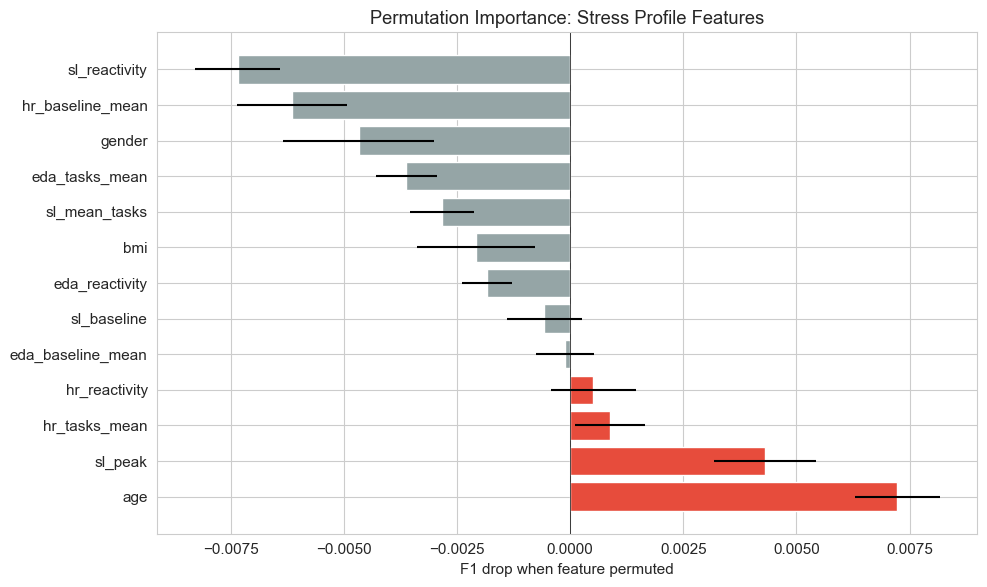


Saved → D:\Github\afc_lab\results_v8_stress\profile_importance.csv


In [25]:
# ── Ablation: v7 baseline (no profile) vs v8.1 (with profile) ──
# Train a model with zero profiles (same architecture, same data, same split)

print("=" * 70)
print("ABLATION: v7 baseline (no profile) vs v8.1 (with profile)")
print("=" * 70)

# 1. Create zero-profile datasets (same split as v8.1)
zero_profiles_train = np.zeros_like(profiles_train_sm)
zero_profiles_val = np.zeros((len(val_idx), profile_dim), dtype=np.float32)
zero_profiles_test = np.zeros((len(test_idx), profile_dim), dtype=np.float32)

abl_train_ds = FatigueDataset(
    X_imu_train_sm, X_physio_train_sm, y_train_sm, hp_train_sm,
    profiles=zero_profiles_train, augment=True)
abl_val_ds = FatigueDataset(
    X_imu[val_idx], X_physio[val_idx], y_all[val_idx], has_physio[val_idx],
    profiles=zero_profiles_val)
abl_test_ds = FatigueDataset(
    X_imu[test_idx], X_physio[test_idx], y_all[test_idx], has_physio[test_idx],
    profiles=zero_profiles_test)

abl_sampler = WeightedRandomSampler(
    torch.from_numpy(sample_weights).double(), len(y_train_sm), replacement=True)
abl_train_ld = DataLoader(abl_train_ds, batch_size=CONFIG['batch_size'], sampler=abl_sampler)
abl_val_ld = DataLoader(abl_val_ds, batch_size=CONFIG['batch_size'])
abl_test_ld = DataLoader(abl_test_ds, batch_size=CONFIG['batch_size'])

# 2. Train ablation model (same hyperparams, zero profiles)
print("\n--- Training ablation model (v7 baseline, zero profiles) ---")
abl_model = FatigueWristNet(CONFIG).to(DEVICE)
abl_pw = compute_pos_weight(y_train_sm)
abl_crit = FocalLoss(gamma=CONFIG['focal_gamma'],
                     pos_weight=torch.tensor([abl_pw]).to(DEVICE))
abl_opt = optim.AdamW(abl_model.parameters(), lr=CONFIG['lr'],
                      weight_decay=CONFIG['weight_decay'])
abl_sched = optim.lr_scheduler.CosineAnnealingLR(
    abl_opt, T_max=CONFIG['epochs'], eta_min=1e-6)
abl_es = EarlyStopping(patience=CONFIG['patience'], min_delta=CONFIG['min_delta'])

for ep in range(CONFIG['epochs']):
    train_epoch(abl_model, abl_train_ld, abl_opt, abl_crit, DEVICE)
    _, vm = validate(abl_model, abl_val_ld, abl_crit, DEVICE)
    abl_sched.step()

    stop = abl_es(vm['f1_macro'], abl_model)
    if (ep + 1) % 10 == 0:
        print(f"  Epoch {ep+1}: F1={vm['f1_macro']:.4f} (ema={abl_es.ema:.4f})")
    if stop:
        print(f"  Ablation early stop at epoch {ep+1}")
        break

if abl_es.best_model:
    abl_model.load_state_dict(abl_es.best_model)

# 3. Evaluate ablation on test set
_, abl_test_metrics = validate(abl_model, abl_test_ld, abl_crit, DEVICE)

# 4. Comparison table
print("\n" + "=" * 70)
print("ABLATION COMPARISON")
print("=" * 70)

comparison = pd.DataFrame([
    {'Variant': 'v7 baseline (no profile)',
     'F1-macro': abl_test_metrics['f1_macro'],
     'ROC-AUC': abl_test_metrics['roc_auc'],
     'PR-AUC': abl_test_metrics['pr_auc'],
     'Balanced-Acc': abl_test_metrics['balanced_acc']},
    {'Variant': 'v8.1 (with stress profile)',
     'F1-macro': test_metrics['f1_macro'],
     'ROC-AUC': test_metrics['roc_auc'],
     'PR-AUC': test_metrics['pr_auc'],
     'Balanced-Acc': test_metrics['balanced_acc']},
])
print(comparison.to_string(index=False))

delta_f1 = test_metrics['f1_macro'] - abl_test_metrics['f1_macro']
delta_auc = test_metrics['roc_auc'] - abl_test_metrics['roc_auc']
print(f"\nΔF1  = {delta_f1:+.4f}")
print(f"ΔAUC = {delta_auc:+.4f}")
print(f"Profile contribution: {'positive ✅' if delta_f1 > 0 else 'negative or neutral ⚠️'}")

comparison.to_csv(RESULTS_DIR / 'ablation_comparison.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'ablation_comparison.csv'}")


# ── 5. Permutation Importance of profile features ──
print("\n" + "=" * 70)
print("PERMUTATION IMPORTANCE: Profile Features")
print("=" * 70)

# Use test set + trained v8.1 model
model.eval()
_, base_metrics = validate(model, test_loader, criterion, DEVICE)
base_f1 = base_metrics['f1_macro']

importance_scores = {}
test_profiles_orig = profiles_all[test_idx].copy()

for feat_idx, feat_name in enumerate(PROFILE_FEATURES):
    f1_drops = []
    for rep in range(5):  # 5 permutation repeats
        # Permute one feature across test samples
        perm_profiles = test_profiles_orig.copy()
        rng = np.random.RandomState(SEED + rep)
        perm_profiles[:, feat_idx] = rng.permutation(perm_profiles[:, feat_idx])

        # Create permuted test dataset
        perm_ds = FatigueDataset(
            X_imu[test_idx], X_physio[test_idx],
            y_all[test_idx], has_physio[test_idx],
            profiles=perm_profiles)
        perm_ld = DataLoader(perm_ds, batch_size=CONFIG['batch_size'], shuffle=False)

        _, perm_metrics = validate(model, perm_ld, criterion, DEVICE)
        f1_drops.append(base_f1 - perm_metrics['f1_macro'])

    importance_scores[feat_name] = {
        'mean_drop': np.mean(f1_drops),
        'std_drop': np.std(f1_drops),
    }

# Sort by importance
imp_df = pd.DataFrame([
    {'Feature': k, 'F1_drop_mean': v['mean_drop'], 'F1_drop_std': v['std_drop']}
    for k, v in importance_scores.items()
]).sort_values('F1_drop_mean', ascending=False)

print(imp_df.to_string(index=False))
print(f"\nBase F1 (all features): {base_f1:.4f}")

# Plot importance
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#95a5a6' for v in imp_df['F1_drop_mean']]
ax.barh(imp_df['Feature'], imp_df['F1_drop_mean'], xerr=imp_df['F1_drop_std'],
        color=colors, edgecolor='white')
ax.set_xlabel('F1 drop when feature permuted')
ax.set_title('Permutation Importance: Stress Profile Features')
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'profile_importance_v81.png', dpi=150)
plt.show()

imp_df.to_csv(RESULTS_DIR / 'profile_importance.csv', index=False)
print(f"\nSaved → {RESULTS_DIR / 'profile_importance.csv'}")

## Итоги v8.1

**Ключевое решение v8.1: Stress Profile Embedding**

v7.0 показал F1=0.80 на exercise-only (AEROBIC + ANAEROBIC, ~31 субъект).
v8.0 попытка добавить STRESS-окна в обучение ухудшила качество (конфликт семантики меток).
v8.1 использует STRESS **не как обучающие данные**, а как **источник индивидуального профиля**.

| Аспект | v7.0 | v8.0 | **v8.1** |
|--------|------|------|----------|
| Данные обучения | AEROBIC + ANAEROBIC | AEROBIC + ANAEROBIC + STRESS | **AEROBIC + ANAEROBIC (exercise-only)** |
| STRESS использование | — | Обучающие окна | **Стресс-профиль (13 фич/субъект)** |
| Модель | FatigueWristNet | FatigueWristNet | **FatigueWristNet + Profile** |
| Profile features | — | — | **Self-reported (4) + HR/EDA react. (6) + Demo (3)** |
| Profile dropout | — | — | **p=0.3 (anti-shortcut)** |
| Classifier input | 24 | 24 | **37 (24 + 13 profile)** |
| Ablation | — | Exercise vs Exercise+STRESS | **No-profile vs With-profile** |
| Feature importance | — | — | **Permutation importance** |

---

### Физиологическое обоснование

Stress Profile Embedding основан на гипотезе, что **индивидуальная стресс-реактивность** предиктивна для физической усталости:

1. **HR reactivity** — люди с сильным сердечно-сосудистым откликом на когнитивный стресс могут быстрее уставать физически
2. **EDA reactivity** — sympathetic nervous system activation коррелирует между стрессом и усталостью
3. **Self-reported stress** — субъективная оценка стрессоустойчивости → прокси для resilience
4. **Demographics** — возраст, BMI, пол влияют на cardiovascular fitness и patterns утомления

### Преимущество подхода

- **Нет конфликта меток** — STRESS не участвует в обучении (label=fatigue только из exercise)
- **Нет data leakage** — profile per-subject, split per-subject
- **Profile dropout** — модель не может полагаться только на статический профиль, должна использовать динамические сигналы
- **Интерпретируемость** — permutation importance показывает, какие стресс-характеристики наиболее предиктивны

### Сравнение версий

| Версия | Данные | Hold-out F1 | LOSO F1 | Примечание |
|--------|--------|-------------|---------|------------|
| v5.1 | Zenodo + 4TU (поясница) | ~0.71 | — | IMU-only, другой сегмент |
| v6.0 | PhysioNet + WSD4FEDSRM | 0.747 | — | Конфликт доменов |
| v7.0 | PhysioNet (exercise) | 0.801 | 0.824 | Базовая линия |
| v8.0 | PhysioNet (exercise + STRESS окна) | ~0.65 | — | Конфликт семантики ↓ |
| **v8.1** | **Exercise + Stress Profile** | **TBD** | **TBD** | **Profile embedding** |

*Значения TBD заполнятся после запуска ноутбука.*

---

### Будущая работа

1. **Per-user pre-training** (Вариант 3 из анализа): pre-train энкодер на STRESS-данных субъекта → fine-tune на его exercise-данных
2. **PCA profile**: если переобучение → сжать 13 фич до 4-6 через PCA
3. **Temporal profile**: использовать динамику HR/EDA в течение STRESS-сессии (не только средние)